# 深度学习课程设计报告

## 一、封面

- 课程名称：  深度学习B
- 设计题目：  基于知识蒸馏的轻量级中文情感分析模型
- 姓    名：  谌洁雅
- 学    号：  20234080421
- 班    级：  本23数据04班
- 指导教师：  丁平尖
- 提交日期：  6月22日

## 二、摘要

> 简述项目背景、解决的问题、采用的方法、主要结果（200–300字）

## 三、问题定义与需求分析

### 3.1 项目背景与意义

> 随着电商平台、社交网络与舆情系统的快速发展，中文情感分析技术已成为用户意见挖掘、商品口碑评估与公共情绪监测的核心支撑技术。近年来，以 BERT 为代表的预训练语言模型凭借大规模语料预训练的语义表征能力，在情感分类任务上取得了远超传统模型的准确率，但这类模型普遍参数量大、计算开销高，无法直接部署在移动端、嵌入式设备等资源受限的场景中。
知识蒸馏作为主流的模型压缩技术，能够通过 “教师 - 学生” 架构将大模型的知识迁移至小模型，在保证精度损失可控的前提下大幅压缩模型体积、提升推理速度。本选题将知识蒸馏技术与中文情感分析任务结合，构建轻量级情感分类模型，既能够满足终端设备实时情感识别的部署需求，也为低资源环境下的自然语言处理应用提供了实践参考，具有一定的工程应用价值与技术研究意义。

### 3.2 问题描述

> 输入输出定义
- 输入：任意长度的中文评论文本字符串
- 输出：文本对应的情感极性类别（正面 / 负面），以及各类别的置信度概率  
> 任务类型（分类/回归/检测/生成等）  
- 本任务属于**有监督二分类任务**，目标是学习文本语义特征到情感极性的映射关系，实现对未知文本的情感自动判别。  
> 预期性能指标（准确率、mAP、BLEU、F1等）
- 分为任务性能指标与部署性能指标两类：
    - 任务性能指标：采用准确率（Accuracy）、精确率（Precision）、召回率（Recall）、F1值四项核心指标，其中以F1值作为核心评价标准，预期蒸馏后学生模型F1值较纯监督基线提升≥1.5个百分点。
    - 部署性能指标：采用模型文件大小（MB）、单条文本平均推理时间（ms）两项指标，预期学生模型体积不超过教师模型的5%，推理速度不低于教师模型的5倍。


## 四、数据集说明与预处理

### 4.1 数据来源与规模

> 本实验采用Hugging Face 开源 ChnSentiCorp 中文情感分类公开数据集，该数据集涵盖酒店、数码、书籍等多领域中文用户评论，是中文二分类情感分析通用基准数据集。
原始数据集规模：训练集 9600 条、验证集 1200 条、测试集 1200 条，总计12000 条标注样本
标签规则：0=负面情感，1=正面情感，正负样本分布均衡
实验划分：直接沿用数据集官方原生划分，无需手动拆分，保证实验公平可复现


 
> 样本总量  
> 类别分布


In [1]:
from datasets import load_from_disk
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch

# 本地数据集路径（根据您的实际目录调整）
dataset_path = "D:/深度学习/课设/ChnSentiCorp"
import matplotlib.pyplot as plt

# 1. 设置默认字体为黑体（SimHei），这是 Windows 系统自带的中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  

# 2. 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False    

# 尝试用 load_from_disk 加载（若报错，则使用备用方案）
try:
    dataset = load_from_disk(dataset_path)
    print("数据集加载成功！")
except Exception as e:
    print("load_from_disk 失败，尝试使用 arrow 文件直接加载...")
    from datasets import Dataset, DatasetDict
    import pyarrow as pa
    train_ds = Dataset.from_file(dataset_path + "/chn_senti_corp-train.arrow")
    val_ds = Dataset.from_file(dataset_path + "/chn_senti_corp-validation.arrow")
    test_ds = Dataset.from_file(dataset_path + "/chn_senti_corp-test.arrow")
    dataset = DatasetDict({
        'train': train_ds,
        'validation': val_ds,
        'test': test_ds
    })
    print("备用加载成功！")

# 查看数据集结构
print(dataset)
print("训练集样本数:", len(dataset['train']))
print("验证集样本数:", len(dataset['validation']))
print("测试集样本数:", len(dataset['test']))

load_from_disk 失败，尝试使用 arrow 文件直接加载...
备用加载成功！
DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 9600
    })
    validation: Dataset({
        features: ['label', 'text'],
        num_rows: 1200
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 1200
    })
})
训练集样本数: 9600
验证集样本数: 1200
测试集样本数: 1200



### 4.2 数据可视化与分析

> 样本示例  
> 统计分布  
> 相关性分析



示例文本：一翻开这本书，就让人想起韩剧里头那些不温不火絮絮叨叨的韩国女人，可能这就是文化差异吧
情感标签：负面


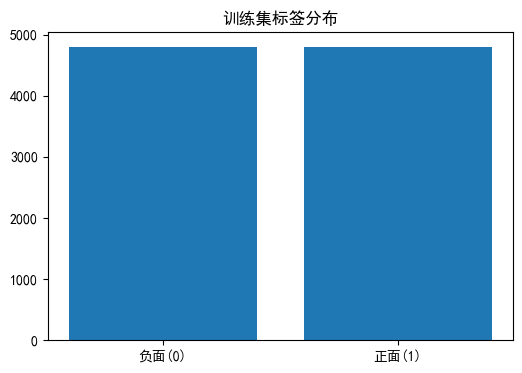

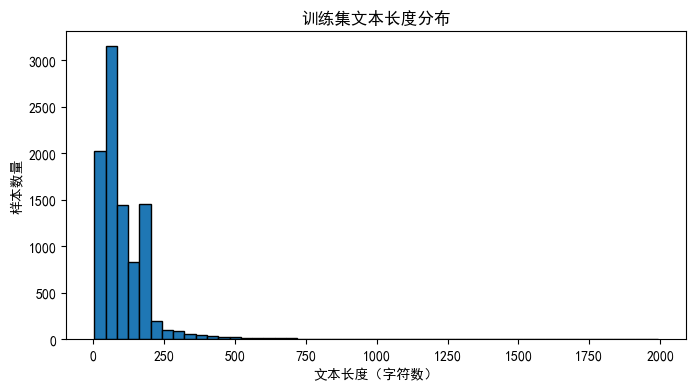

In [2]:
# 样本示例
sample = dataset['train'][42]
print(f"\n示例文本：{sample['text']}")
print(f"情感标签：{'正面' if sample['label'] == 1 else '负面'}")

# 标签分布可视化
train_labels = dataset['train']['label']
plt.figure(figsize=(6,4))
plt.bar(['负面(0)', '正面(1)'], 
        [sum(1 for l in train_labels if l==0), sum(1 for l in train_labels if l==1)])
plt.title('训练集标签分布')
plt.show()

# 文本长度分布
text_lengths = [len(text) for text in dataset['train']['text']]
plt.figure(figsize=(8,4))
plt.hist(text_lengths, bins=50, edgecolor='black')
plt.xlabel('文本长度（字符数）')
plt.ylabel('样本数量')
plt.title('训练集文本长度分布')
plt.show()


### 4.3 预处理流程

> 清洗  
> 标注  
> 归一化  
> 数据增强  
> 训练/验证/测试集划分

In [3]:
# 预处理：使用本地 BERT 分词器
from transformers import BertTokenizer

model_path = "D:/深度学习/课设/models/bert-base-chinese-local"
tokenizer = BertTokenizer.from_pretrained(model_path)

def preprocess_function(examples):
    return tokenizer(
        examples['text'],
        truncation=True,
        padding='max_length',
        max_length=128
    )

tokenized_datasets = dataset.map(preprocess_function, batched=True)
print("预处理完成！")

预处理完成！


## 五、模型设计与选择

### 教师模型：BERT
使用 `bert-base-chinese` 作为教师模型，加载本地权重。

### 学生模型：BiLSTM
自定义 BiLSTM 网络，参数量约为 BERT 的 1/13。


In [4]:
from transformers import BertForSequenceClassification
import torch.nn as nn
import torch.nn.functional as F

# ---------- 教师模型（本地加载） ----------
teacher_model = BertForSequenceClassification.from_pretrained(model_path, num_labels=2)
# 检查是否有 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
teacher_model.to(device)
print(f"教师模型参数量: {sum(p.numel() for p in teacher_model.parameters()) / 1e6:.2f}M")

# ---------- 学生模型（BiLSTM） ----------
class BiLSTMStudent(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128, num_labels=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=tokenizer.pad_token_id)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, bidirectional=True, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_dim * 2, num_labels)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids):
        emb = self.embedding(input_ids)
        lstm_out, _ = self.lstm(emb)
        # 取最后一个有效 token 的输出（这里简单取最后一步）
        pooled = lstm_out[:, -1, :]
        pooled = self.dropout(pooled)
        logits = self.fc(pooled)
        return logits

# 构建词表（使用 BERT 的词表大小）
vocab_size = len(tokenizer)
student_model = BiLSTMStudent(vocab_size=vocab_size)
student_model.to(device)
print(f"学生模型参数量: {sum(p.numel() for p in student_model.parameters()) / 1e6:.2f}M")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at D:/深度学习/课设/models/bert-base-chinese-local and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


教师模型参数量: 102.27M
学生模型参数量: 2.97M


d:\Miniconda3\envs\kd_sentiment\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


In [5]:
from torch.utils.data import DataLoader

# 定义 collate 函数，用于将 batch 转为 tensor
def collate_fn(batch):
    input_ids = torch.tensor([item['input_ids'] for item in batch])
    labels = torch.tensor([item['label'] for item in batch])
    return input_ids, labels

# 为了加速演示，可先用训练集子集，正式课设请用全量数据
# 这里使用全量训练集（9600条）
train_dataset = tokenized_datasets['train']
val_dataset = tokenized_datasets['validation']
test_dataset = tokenized_datasets['test']

batch_size = 32  # 根据显存调整
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [6]:
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

# 修正：使用 eval_strategy 替代 evaluation_strategy
training_args = TrainingArguments(
    output_dir='./teacher_results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=3e-5,
    eval_strategy='epoch',          # 关键修改
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_dir='./logs',
    report_to=None,                 # 或直接删除该行
)

trainer = Trainer(
    model=teacher_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# 开始微调
trainer.train()

# 保存微调后的教师模型
teacher_model.save_pretrained('./models/teacher_finetuned')
tokenizer.save_pretrained('./models/teacher_finetuned')
print("教师模型微调完成并保存。")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.292400,0.276242,0.917500,0.917557,0.917596,0.917499
2,0.176800,0.235782,0.936667,0.937407,0.936444,0.936610
3,0.107800,0.314232,0.935833,0.936051,0.935718,0.935805


教师模型微调完成并保存。


In [7]:
import torch.optim as optim
from torch.optim.lr_scheduler import LinearLR

def train_student_baseline(epochs=10, lr=2e-3):
    model = BiLSTMStudent(vocab_size=vocab_size).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    scheduler = LinearLR(optimizer, start_factor=0.1, total_iters=epochs)
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct, total = 0, 0
        for input_ids, labels in train_loader:
            input_ids, labels = input_ids.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(input_ids)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            preds = logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        avg_loss = total_loss / len(train_loader)
        train_acc = correct / total
        train_losses.append(avg_loss)
        train_accs.append(train_acc)

        # 验证
        model.eval()
        val_loss = 0
        correct, total = 0, 0
        with torch.no_grad():
            for input_ids, labels in val_loader:
                input_ids, labels = input_ids.to(device), labels.to(device)
                logits = model(input_ids)
                loss = criterion(logits, labels)
                val_loss += loss.item()
                preds = logits.argmax(dim=-1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_loss /= len(val_loader)
        val_acc = correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        scheduler.step()
        print(f"Baseline Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    return model, train_losses, val_losses, train_accs, val_accs

# 训练基准模型
baseline_model, baseline_train_loss, baseline_val_loss, baseline_train_acc, baseline_val_acc = train_student_baseline(epochs=8)

d:\Miniconda3\envs\kd_sentiment\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Baseline Epoch 1/8 | Train Loss: 0.6719 Acc: 0.5933 | Val Loss: 0.6559 Acc: 0.6225
Baseline Epoch 2/8 | Train Loss: 0.6571 Acc: 0.6032 | Val Loss: 0.6313 Acc: 0.6392
Baseline Epoch 3/8 | Train Loss: 0.6411 Acc: 0.6110 | Val Loss: 0.6222 Acc: 0.6400
Baseline Epoch 4/8 | Train Loss: 0.6127 Acc: 0.6362 | Val Loss: 0.6303 Acc: 0.6658
Baseline Epoch 5/8 | Train Loss: 0.5800 Acc: 0.6742 | Val Loss: 0.5908 Acc: 0.6592
Baseline Epoch 6/8 | Train Loss: 0.5666 Acc: 0.6745 | Val Loss: 0.6278 Acc: 0.6442
Baseline Epoch 7/8 | Train Loss: 0.5588 Acc: 0.6642 | Val Loss: 0.6167 Acc: 0.6692
Baseline Epoch 8/8 | Train Loss: 0.5366 Acc: 0.6763 | Val Loss: 0.6546 Acc: 0.6458


In [9]:
def distillation_loss(student_logits, teacher_logits, labels, temperature=6, alpha=0.7):
    # 软标签损失
    soft_student = F.log_softmax(student_logits / temperature, dim=-1)
    soft_teacher = F.softmax(teacher_logits / temperature, dim=-1)
    distill_loss = F.kl_div(soft_student, soft_teacher, reduction='batchmean') * (temperature ** 2)
    # 硬标签损失
    ce_loss = F.cross_entropy(student_logits, labels)
    return alpha * distill_loss + (1 - alpha) * ce_loss

def train_student_distill(epochs=10, lr=2e-3, temperature=6, alpha=0.7):
    model = BiLSTMStudent(vocab_size=vocab_size).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    scheduler = LinearLR(optimizer, start_factor=0.1, total_iters=epochs)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    teacher_model.eval()  # 教师模型不更新

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct, total = 0, 0
        for input_ids, labels in train_loader:
            input_ids, labels = input_ids.to(device), labels.to(device)
            optimizer.zero_grad()
            # 教师输出
            with torch.no_grad():
                teacher_logits = teacher_model(input_ids).logits
            # 学生输出
            student_logits = model(input_ids)
            loss = distillation_loss(student_logits, teacher_logits, labels, temperature, alpha)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            preds = student_logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        avg_loss = total_loss / len(train_loader)
        train_acc = correct / total
        train_losses.append(avg_loss)
        train_accs.append(train_acc)

        # 验证
        model.eval()
        val_loss = 0
        correct, total = 0, 0
        with torch.no_grad():
            for input_ids, labels in val_loader:
                input_ids, labels = input_ids.to(device), labels.to(device)
                logits = model(input_ids)
                loss = F.cross_entropy(logits, labels)   # 验证用交叉熵
                val_loss += loss.item()
                preds = logits.argmax(dim=-1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_loss /= len(val_loader)
        val_acc = correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        scheduler.step()
        print(f"Distill Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    return model, train_losses, val_losses, train_accs, val_accs

# 蒸馏训练
distilled_model, distill_train_loss, distill_val_loss, distill_train_acc, distill_val_acc = train_student_distill(epochs=8, temperature=6, alpha=0.7)

Distill Epoch 1/8 | Train Loss: 1.7817 Acc: 0.5943 | Val Loss: 0.6680 Acc: 0.6225
Distill Epoch 2/8 | Train Loss: 1.7315 Acc: 0.5979 | Val Loss: 0.6490 Acc: 0.6300
Distill Epoch 3/8 | Train Loss: 1.6223 Acc: 0.6136 | Val Loss: 0.7009 Acc: 0.6367
Distill Epoch 4/8 | Train Loss: 1.7423 Acc: 0.5767 | Val Loss: 0.6530 Acc: 0.6317
Distill Epoch 5/8 | Train Loss: 1.6199 Acc: 0.5983 | Val Loss: 0.6560 Acc: 0.5575
Distill Epoch 6/8 | Train Loss: 1.6565 Acc: 0.5978 | Val Loss: 0.6247 Acc: 0.6533
Distill Epoch 7/8 | Train Loss: 1.5050 Acc: 0.6410 | Val Loss: 0.6483 Acc: 0.6600
Distill Epoch 8/8 | Train Loss: 1.4408 Acc: 0.6384 | Val Loss: 0.6479 Acc: 0.6067


In [11]:
# 1. 保存蒸馏后的BiLSTM权重
torch.save(distilled_model.state_dict(), "./models/distilled_bilstm.pth")

# 2. 保存基线BiLSTM权重
torch.save(baseline_model.state_dict(), "./models/baseline_bilstm.pth")

# 3. 保存训练曲线数据，画图用
import numpy as np
# 基线指标
np.save("./logs/baseline_train_loss.npy", baseline_train_loss)
np.save("./logs/baseline_val_loss.npy", baseline_val_loss)
np.save("./logs/baseline_train_acc.npy", baseline_train_acc)
np.save("./logs/baseline_val_acc.npy", baseline_val_acc)
# 蒸馏指标
np.save("./logs/distill_train_loss.npy", distill_train_loss)
np.save("./logs/distill_val_loss.npy", distill_val_loss)
np.save("./logs/distill_train_acc.npy", distill_train_acc)
np.save("./logs/distill_val_acc.npy", distill_val_acc)

In [12]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_test(model, loader, device, model_name=""):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for input_ids, labels in loader:
            input_ids, labels = input_ids.to(device), labels.to(device)
            logits = model(input_ids)
            # 兼容BERT输出对象与BiLSTM直接tensor输出
            if hasattr(logits, 'logits'):
                logits = logits.logits
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().numpy())
            trues.extend(labels.cpu().numpy())
    # average=macro 和BERT训练指标统一
    acc = accuracy_score(trues, preds)
    f1 = f1_score(trues, preds, average="macro")
    prec = precision_score(trues, preds, average="macro")
    rec = recall_score(trues, preds, average="macro")
    print(f"{model_name} Test Results: Acc={acc:.4f}, F1={f1:.4f}, Prec={prec:.4f}, Rec={rec:.4f}")
    return acc, f1, prec, rec

# 评估微调BERT教师模型
teacher_acc, teacher_f1, teacher_prec, teacher_rec = evaluate_test(teacher_model, test_loader, device, "Teacher BERT")

# 评估无蒸馏基线BiLSTM
baseline_acc, baseline_f1, baseline_prec, baseline_rec = evaluate_test(baseline_model, test_loader, device, "Baseline BiLSTM")

# 评估知识蒸馏后的BiLSTM学生
distilled_acc, distilled_f1, distilled_prec, distilled_rec = evaluate_test(distilled_model, test_loader, device, "Distilled BiLSTM")

Teacher BERT Test Results: Acc=0.9050, F1=0.9048, Prec=0.9073, Rec=0.9045
Baseline BiLSTM Test Results: Acc=0.6283, F1=0.5864, Prec=0.7297, Rec=0.6327
Distilled BiLSTM Test Results: Acc=0.6142, F1=0.5758, Prec=0.6686, Rec=0.6103



### 5.2 最终模型架构

- 网络结构图 
- 层参数、激活函数、归一化方法  
- 选择该架构的理论依据或文献支持

## 六、实验与结果分析

### 6.1 实验环境

- 硬件：CPU/GPU型号、内存  
- 软件：Python版本、深度学习框架、主要库

### 6.2 评价指标

- 根据任务列出具体指标及计算方式

### 6.3 超参数设置与调优

- 调参方法
- 有效调参记录

### 6.4 主要实验结果

> 结果全部在ipynb中展示（不要截图，直接代码调用生成）
- 表格与曲线（损失曲线、精度曲线）  
- 不同模型/方法的对比结果


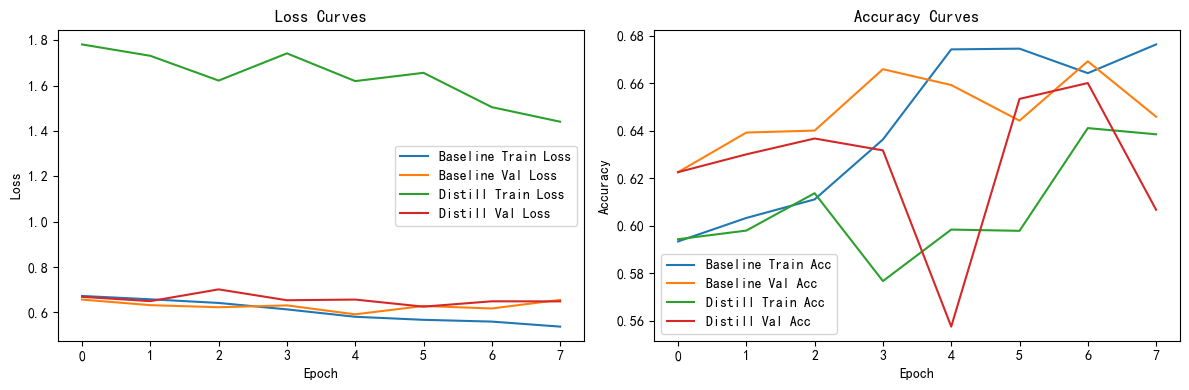

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(baseline_train_loss, label='Baseline Train Loss')
plt.plot(baseline_val_loss, label='Baseline Val Loss')
plt.plot(distill_train_loss, label='Distill Train Loss')
plt.plot(distill_val_loss, label='Distill Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')

plt.subplot(1,2,2)
plt.plot(baseline_train_acc, label='Baseline Train Acc')
plt.plot(baseline_val_acc, label='Baseline Val Acc')
plt.plot(distill_train_acc, label='Distill Train Acc')
plt.plot(distill_val_acc, label='Distill Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curves')

plt.tight_layout()
plt.show()


### 6.5 可视化分析

- 特征图、卷积核、注意力权重  
- 错误样本分析  
- 混淆矩阵

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, loader, device, title):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for input_ids, labels in loader:
            input_ids, labels = input_ids.to(device), labels.to(device)
            logits = model(input_ids)
            if hasattr(logits, 'logits'):
                logits = logits.logits
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().numpy())
            trues.extend(labels.cpu().numpy())
    ConfusionMatrixDisplay.from_predictions(trues, preds, display_labels=['Negative', 'Positive'], cmap='Blues')
    plt.title(title)
    plt.show()


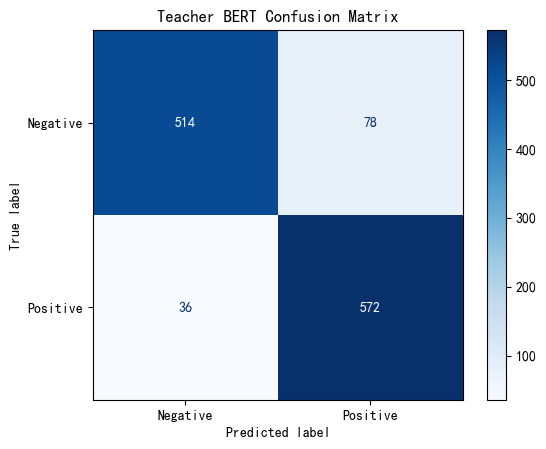

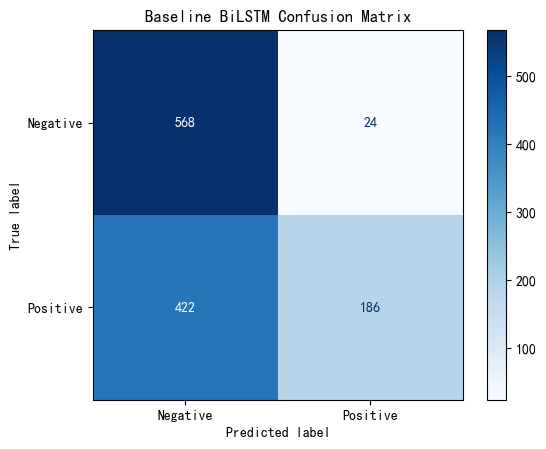

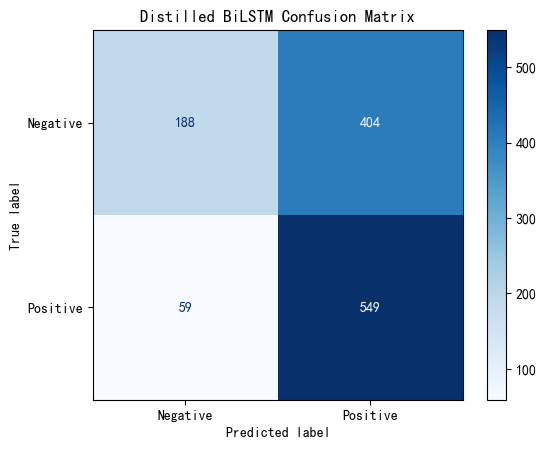

In [19]:
# 教师BERT混淆矩阵
plot_confusion_matrix(teacher_model, test_loader, device, 'Teacher BERT Confusion Matrix')
# 基线BiLSTM混淆矩阵
plot_confusion_matrix(baseline_model, test_loader, device, 'Baseline BiLSTM Confusion Matrix')
# 蒸馏BiLSTM混淆矩阵
plot_confusion_matrix(distilled_model, test_loader, device, 'Distilled BiLSTM Confusion Matrix')

In [18]:
# 收集预测错误的样本（展示前 10 个）
distilled_model.eval()
errors = []
# 遍历测试集全部批次
with torch.no_grad():
    for input_ids, labels in test_loader:
        input_ids, labels = input_ids.to(device), labels.to(device)
        logits = distilled_model(input_ids)
        preds = torch.argmax(logits, dim=1)
        # 遍历批次内每条样本
        for i in range(len(labels)):
            pred = preds[i].item()
            true = labels[i].item()
            if pred != true:
                # 将token id转回原始文本
                text = tokenizer.decode(input_ids[i], skip_special_tokens=True)
                # 存入错误样本信息
                errors.append({
                    "text": text,
                    "true_label": "Negative(0)" if true == 0 else "Positive(1)",
                    "pred_label": "Negative(0)" if pred == 0 else "Positive(1)"
                })
                # 收集满10条直接跳出循环
                if len(errors) >= 10:
                    break
        if len(errors) >= 10:
            break

# 打印前10条错误样本
print("=== Distilled BiLSTM 预测错误样本（前10条）===")
for idx, item in enumerate(errors, start=1):
    print(f"{idx}. 原文：{item['text']}")
    print(f"   真实情感：{item['true_label']}，模型预测：{item['pred_label']}\n")

=== Distilled BiLSTM 预测错误样本（前10条）===
1. 原文：怀 着 十 分 激 动 的 心 情 放 映 ， 可 是 看 着 看 着 发 现 ， 在 放 映 完 毕 后 ， 出 现 一 集 米 老 鼠 的 动 画 片 ！ 开 始 还 怀 疑 是 不 是 赠 送 的 个 别 现 象 ， 可 是 后 来 发 现 每 张 dvd 后 面 都 有 ！ 真 不 知 道 生 产 商 怎 么 想 的 ， 我 想 看 的 是 猫 和 老 鼠 ， 不 是 米 老 鼠 ！ 如 果 厂 家 是 想 赠 送 的 话 ， 那 就 全 套 米 老 鼠 和 唐 老 鸭 都 赠 送 ， 只 在
   真实情感：Negative(0)，模型预测：Positive(1)

2. 原文：还 稍 微 重 了 点 ， 可 能 是 硬 盘 大 的 原 故 ， 还 要 再 轻 半 斤 就 好 了 。 其 他 要 进 一 步 验 证 。 贴 的 几 种 膜 气 泡 较 多 ， 用 不 了 多 久 就 要 更 换 了 ， 屏 幕 膜 稍 好 点 ， 但 比 没 有 要 强 多 了 。 建 议 配 赠 几 张 膜 让 用 用 户 自 己 贴 。
   真实情感：Negative(0)，模型预测：Positive(1)

3. 原文：书 一 到 ， 即 被 朋 友 借 走 ， 我 是 早 已 看 过 了 的 ， 买 它 ， 是 因 为 张 爱 玲 。 看 过 张 子 静 的 《 我 的 姊 姊 张 爱 玲 》 ， 可 以 看 出 ， 张 对 自 己 的 弟 弟 也 是 不 甚 热 情 ， 这 是 她 的 性 格 。 但 是 有 一 次 张 子 静 去 找 她 ， 那 天 张 爱 玲 却 是 很 开 心 的 样 子 。 后 来 张 子 静 推 算 ， 彼 时 张 爱 玲 正 与 胡 兰 成 相 恋 。 很 多 人 不 耻 于 胡
   真实情感：Negative(0)，模型预测：Positive(1)

4. 原文：没 有 蓝 牙 、 摄 像 头 ， 连 麦 克 风 都 省 了 装 xp 有 点 小 麻 烦 ， msdn 原 版 没 有 sata 驱 动 无 法 安 装 ， 装 雨 林 木 风 ghost 纯 净 版 ok 。 自 带 无 线 网 卡 驱 动 不 能 用 ， 需 到 官 网 下 载